In [350]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [351]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# A

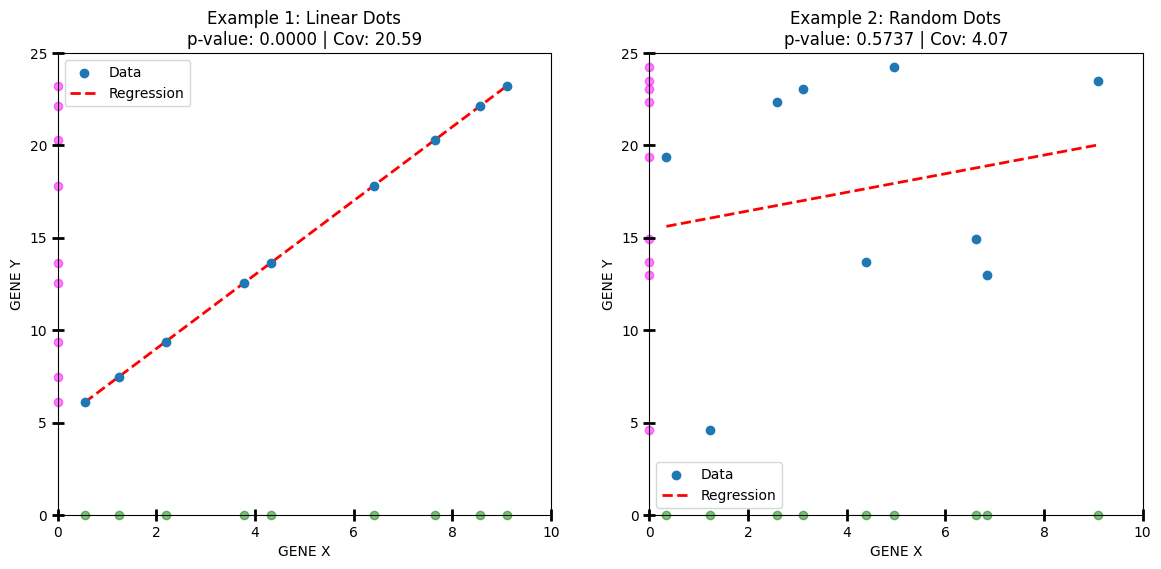

In [352]:
#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def processar_grafico(ax, x, y, title):
    #linear regression
    res = stats.linregress(x, y)
    
    #covariance
    cov_matrix = np.cov(x, y)
    cov_val = cov_matrix[0, 1]

    #p value
    p_value = res.pvalue

    #dots and projections
    ax.scatter(x, y, zorder=3, label='Data')
    ax.scatter(x, [0]*len(x), color='green', alpha=0.5, clip_on=False)
    ax.scatter([0]*len(y), y, color='magenta', alpha=0.5, clip_on=False)

    #linear regression line
    lx = np.linspace(min(x), max(x), 100)
    ly = res.slope * lx + res.intercept
    ax.plot(lx, ly, color='red', linestyle='--', linewidth=2, label='Regression')

    #plot config
    ax.set_title(f"{title}\np-value: {p_value:.4f} | Cov: {cov_val:.2f}")

    ax.set_xlabel("GENE X")
    ax.set_ylabel("GENE Y")
    ax.set_xlim(0, 10); ax.set_ylim(0, 25)
    ax.tick_params(direction='inout', length=8, width=2)
    ax.legend()


#FIRST GRAPH
#data [0, 10]
x1 = [1.24, 8.57, 4.32, 0.55, 9.12, 3.78, 6.41, 2.19, 7.65]
y1 = [7.48, 22.14, 13.64, 6.10, 23.24, 12.56, 17.82, 9.38, 20.30]

processar_grafico(ax1, x1, y1, "Example 1: Linear Dots")

#SECOND GRAPH (RANDOM)
#data [0, 10]
x2 = np.random.uniform(0, 10, 9)
y2 = np.random.uniform(0, 25, 9)

processar_grafico(ax2, x2, y2, "Example 2: Random Dots")

# Interpretação dos dados da questão A:

* **Função linregress**:
    * Encontra a reta que melhor representa os dados.

* **P-Value**:
    * **Gráfico 1 (Linear)**: O p-value é 0, ou seja, a relação entre os dados é real e significativa.
    * **Gráfico 2 (Aleatório)**: O p-value normalmente é alto (maior que 0.05), ou seja, a reta é apenas uma coincidência e os dados não têm relação entre si.

* **Covariância**:
    * A covariância mede se os genes (X e Y) variam juntos e em qual direção.
    * Se a covariância estiver mais perto de 0, menor é a relação entre os genes e mais dificíl de prever resultados.

---

# B

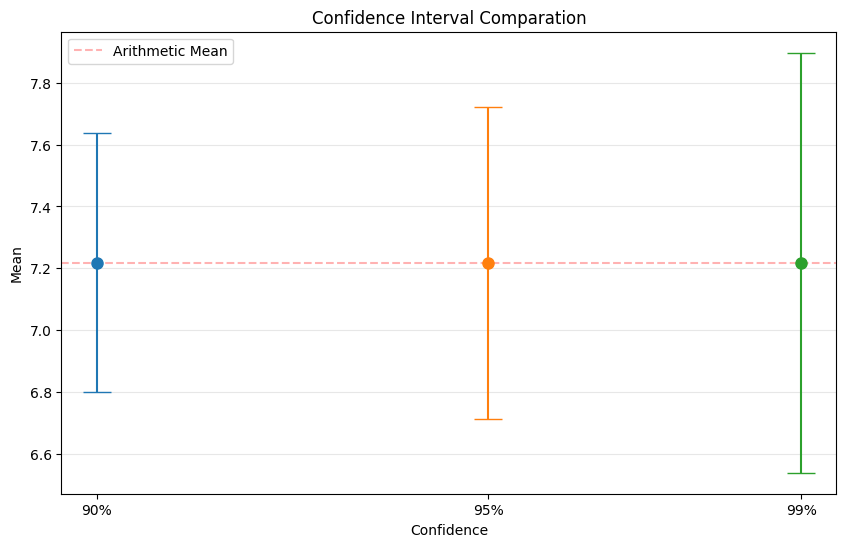

In [ ]:
#seed
np.random.seed(42)

#data, arithmetic mean and standard deviation
data = np.random.normal(loc=7.5, scale=1.5, size=30)
arithmetic_mean = np.mean(data)
standard_deviation = np.std(data, ddof=1)

#confidences intervals
n = len(data)
confidences = [0.90, 0.95, 0.99]
intervals = []

for conf in confidences:
    interval = stats.t.interval(conf, df=n-1, loc=arithmetic_mean, scale=stats.sem(data))
    intervals.append(interval)

#error bars
plt.figure(figsize=(10, 6))
for i, (conf, inter) in enumerate(zip(confidences, intervals)):
    error = (inter[1] - inter[0]) / 2
    plt.errorbar(conf, arithmetic_mean, yerr=error, fmt='o', capsize=10,  markersize=8)

#plot config
plt.axhline(arithmetic_mean, color='red', linestyle='--', alpha=0.3, label='Arithmetic Mean')
plt.title('Confidence Interval Comparation')
plt.xlabel('Confidence')
plt.ylabel('Mean')
plt.xticks(confidences, ['90%', '95%', '99%'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()